# PCA plot

## Objective

This project performs PCA on the data  to study differences between ER+ and ER− samples.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

## Loading the Dataset

The dataset files are loaded using pandas.

In [7]:
expression_data = pd.read_csv(
    "filtered.tsv.gz",
    sep="\t",
    compression="gzip"
)

class_labels = pd.read_csv(
    "class.tsv",
    sep="\t",
    header=None
)

print("Expression Data Shape:",
      expression_data.shape)

print("Class Labels Shape:",
      class_labels.shape)

Expression Data Shape: (105, 16174)
Class Labels Shape: (105, 1)


## Previewing the Dataset

The first few rows are displayed to understand the structure of the dataset.

In [8]:
expression_data.head()

,1,2,6,12,13,15,16,17,20,25,...,27622,27623,27633,27634,27638,27641,27642,27643,27644,27648
0,0.0534,0.2558,-1.1449,-0.3843,0.4021,0.3512,-0.9012,0.7222,-0.7375,0.2280,...,-0.2210,0.5787,0.7728,0.0400,-0.9146,0.6340,0.6287,1.2642,-1.0183,0.0125
1,0.4866,0.4736,-0.1135,0.1500,0.6200,-0.0146,-0.8901,0.2130,-0.6469,0.4252,...,-0.0877,0.5425,0.4749,-0.3254,-0.1769,0.4156,0.7505,1.0079,-0.3954,0.6992
2,0.5908,0.6439,-0.7664,-0.5907,-1.0596,1.2956,-3.7167,1.3004,-1.6517,0.5212,...,0.4996,0.9947,1.6248,-1.5840,-0.8922,0.2501,0.7772,0.9710,-0.0020,1.2096
3,-0.4971,-0.4926,-0.8767,-0.3029,-0.4014,0.7181,-0.5141,1.1114,-0.8361,-0.5792,...,-0.2264,0.8984,1.2040,-0.3831,-0.0856,0.9370,0.2867,2.7123,-0.3660,0.0959
4,0.2970,0.2770,-0.6193,-0.3508,0.0383,-0.2477,0.0367,0.5746,-0.6916,0.2816,...,0.5279,0.9044,-0.0447,0.0892,0.1246,0.6882,1.0088,1.2697,-0.2589,0.0685


## Extracting Gene Expression Values

The expression values of XBP1 and GATA3 are extracted for visualization.

In [10]:
expression_data.columns = (
    expression_data.columns.str.strip()
)

print(expression_data.columns[:50])

Index(['1', '2', '6', '12', '13', '15', '16', '17', '20', '25', '28', '33',
       '34', '36', '38', '43', '46', '49', '52', '54', '55', '56', '58', '59',
       '60', '61', '62', '63', '65', '66', '67', '68', '72', '73', '75', '76',
       '80', '83', '87', '91', '92', '93', '95', '107', '108', '109', '110',
       '111', '113', '116'],
      dtype='object')


## Scatter Plot of Gene Expression

A scatter plot is created using XBP1 and GATA3 expression levels.

In [13]:
labels = class_labels[0]

In [17]:
print(expression_data.columns[50:100])

Index(['117', '118', '119', '120', '122', '126', '128', '130', '131', '132',
       '133', '135', '136', '137', '141', '146', '147', '148', '154', '156',
       '163', '165', '166', '167', '171', '175', '176', '177', '186', '187',
       '188', '189', '190', '192', '195', '196', '204', '206', '214', '216',
       '217', '226', '227', '228', '229', '231', '233', '234', '236', '237'],
      dtype='object')


In [18]:
xbp1_expression = expression_data["2625"]

gata3_expression = expression_data["188"]

labels = class_labels[0]

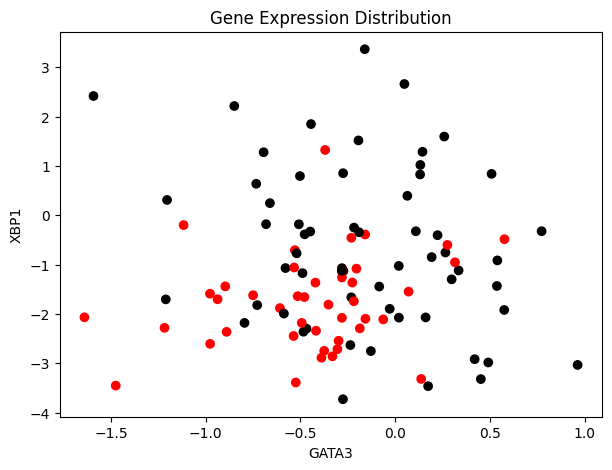

In [19]:
sample_colors = [
    "red" if x == 1 else "black"
    for x in labels
]

plt.figure(figsize=(7,5))

plt.scatter(
    gata3_expression,
    xbp1_expression,
    c=sample_colors
)

plt.xlabel("GATA3")
plt.ylabel("XBP1")

plt.title("Gene Expression Distribution")

plt.show()

## Standardizing the Dataset

The dataset is standardized before PCA analysis.

In [20]:
scaler = StandardScaler()

scaled_data = scaler.fit_transform(expression_data)

## Applying PCA

PCA reduces the high-dimensional dataset into two principal components.

In [21]:
pca = PCA(n_components=2)

principal_components = pca.fit_transform(
    scaled_data
)

pca_df = pd.DataFrame(
    principal_components,
    columns=["PC1", "PC2"]
)

## PCA Visualization

The PCA result is visualized using a scatter plot.

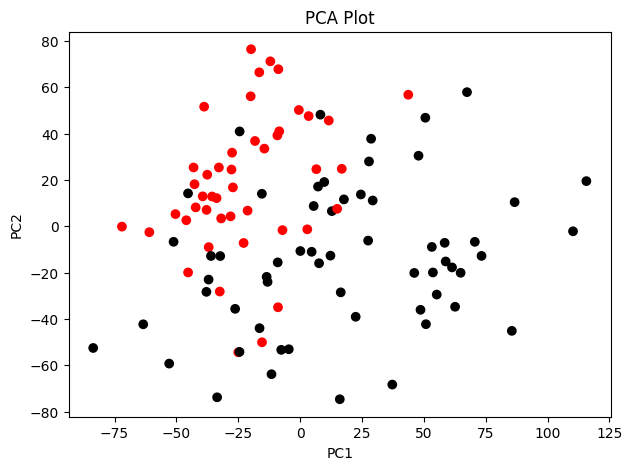

In [22]:
plt.figure(figsize=(7,5))

plt.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    c=sample_colors
)

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.title("PCA Plot")

plt.show()

## Variance Explained

The variance explained by the first two principal components is calculated.

In [23]:
print(
    "PC1 Variance:",
    pca.explained_variance_ratio_[0]
)

print(
    "PC2 Variance:",
    pca.explained_variance_ratio_[1]
)

PC1 Variance: 0.1020231610929902
PC2 Variance: 0.07382827799712047


## Scree Plot

The scree plot shows the variance explained by different principal components.

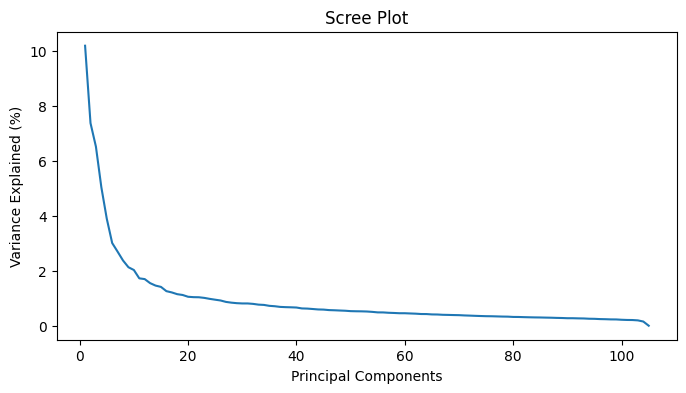

In [24]:
full_pca = PCA()

full_pca.fit(scaled_data)

variance_values = (
    full_pca.explained_variance_ratio_
)

plt.figure(figsize=(8,4))

plt.plot(
    range(1, len(variance_values)+1),
    variance_values * 100
)

plt.xlabel("Principal Components")

plt.ylabel("Variance Explained (%)")

plt.title("Scree Plot")

plt.show()

## Projection onto PC1

Samples are projected onto the first principal component.

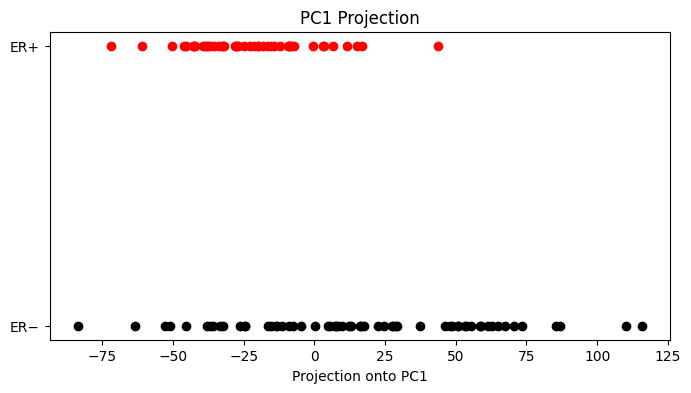

In [25]:
pc1_values = pca_df["PC1"]

plt.figure(figsize=(8,4))

for i in range(len(pc1_values)):

    if labels[i] == 1:
        color = "red"
        y = 1

    else:
        color = "black"
        y = 0

    plt.scatter(
        pc1_values[i],
        y,
        c=color
    )

plt.yticks(
    [0,1],
    ["ER−", "ER+"]
)

plt.xlabel("Projection onto PC1")

plt.title("PC1 Projection")

plt.show()

## Conclusion

PCA successfully reduced the gene expression dataset into smaller dimensions while preserving important patterns.

The analysis also showed visible differences between ER+ and ER− samples.